Лабораторна робота 2. Харченко, ФІТ 3-10

---

# Завдання 1

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
# без User-Agent вікіпедія не віддає сторінку (помилка 403)
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

# беремо таблицю, де є стовпець Country/Territory
df = pd.read_html(StringIO(html), match="Country/Territory")[0]

In [2]:
df.head()

,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


2.	Визначити розмір датасета.

In [3]:
print("Рядків:", df.shape[0])
print("Стовпців:", df.shape[1])

Рядків: 222
Стовпців: 4


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [4]:
print(df.columns.tolist())

# в таблиці 4 стовпці: країна і три оцінки ВВП (млн доларів), всі вони потрібні
# тому прибираємо тільки виноски [1], [n 1] з назв
df.columns = ["Country", "IMF (2026)", "World Bank (2025)", "United Nations (2024)"]
df["Country"] = df["Country"].str.replace(r"\[.*?\]", "", regex=True)

# рядок World - це сума по всіх країнах, а не країна, він тільки зіпсує статистику
df = df[df["Country"] != "World"].reset_index(drop=True)
df.head()

['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]', 'United Nations (2024)[7]']


,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,32383920,30769700,29298000
1,China,20851593,19498039,18743802
2,Germany,5452858,5050923,4659929
3,Japan,4379253,4435163,4026211
4,United Kingdom,4264794,4002588,3685881


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [5]:
cols = ["IMF (2026)", "World Bank (2025)", "United Nations (2024)"]

# зараз пропуски в таблиці записані як "—N/a", тому замінюємо все, що починається з "—"
df[cols] = df[cols].replace(r"^—.*", np.nan, regex=True)

In [6]:
# в деяких числах є коми і рік в дужках, наприклад "1,982 (2019)"
# прибираємо це і переводимо стовпці в числа
for col in cols:
    df[col] = df[col].str.replace(r"\(\d{4}\)", "", regex=True).str.replace(",", "").str.strip()
    df[col] = pd.to_numeric(df[col])

df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [7]:
df.isna().sum()

,0
Country,0
IMF (2026),24
World Bank (2025),7
United Nations (2024),9


In [8]:
# запам'ятовуємо, в яких країнах були пропуски, знадобиться далі
had_nan = df[cols].isna().any(axis=1)
print("Країни з пропусками:", df.loc[had_nan, "Country"].tolist())

# заповнюємо пропуски середнім по стовпцю
df[cols] = df[cols].fillna(df[cols].mean())

Країни з пропусками: ['Taiwan', 'Cuba', 'North Korea', 'Channel Islands', 'Monaco', 'Bermuda', 'New Caledonia', 'Cayman Islands', 'Isle of Man', 'Guam', 'French Polynesia', 'U.S. Virgin Islands', 'Faroe Islands', 'Curaçao', 'Greenland', 'Zanzibar', 'Sint Maarten', 'British Virgin Islands', 'Turks and Caicos Islands', 'Northern Mariana Islands', 'American Samoa', 'Saint Martin', 'Anguilla', 'Cook Islands', 'Montserrat']


In [9]:
df.isna().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [10]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,United States,3.238392e+07,3.076970e+07,29298000.0
1,China,2.085159e+07,1.949804e+07,18743802.0
2,Germany,5.452858e+06,5.050923e+06,4659929.0
3,Japan,4.379253e+06,4.435163e+06,4026211.0
4,United Kingdom,4.264794e+06,4.002588e+06,3685881.0
...,...,...,...,...
216,Palau,3.770000e+02,3.450000e+02,310.0
217,Marshall Islands,3.420000e+02,3.080000e+02,281.0
218,Nauru,1.960000e+02,1.760000e+02,187.0
219,Montserrat,6.412000e+05,5.482661e+05,81.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [11]:
print("Однакових рядків:", df.duplicated().sum())

Однакових рядків: 0


In [12]:
print("Країн, що повторюються:", df["Country"].duplicated().sum())

Країн, що повторюються: 0


In [13]:
df = df.drop_duplicates()
print("Розмір після видалення дублікатів:", df.shape)

Розмір після видалення дублікатів: (221, 4)


7.	Вивести описову статистику датасету describe()

In [14]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,6.412000e+05,5.482661e+05,5.224912e+05
std,2.668734e+06,2.528406e+06,2.410079e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,1.733600e+04,9.194000e+03,8.840000e+03
50%,8.383200e+04,4.549000e+04,4.276500e+04
75%,5.799960e+05,3.062390e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [15]:
diff = df[["Country", "IMF (2026)", "World Bank (2025)"]].copy()
diff["Різниця"] = diff["IMF (2026)"] - diff["World Bank (2025)"]
diff["Різниця по модулю"] = diff["Різниця"].abs()

print("Топ-10 за різницею (всі країни):")
display(diff.sort_values("Різниця по модулю", ascending=False).head(10))

# у країн з пропусками одне значення - це середнє, тому різниця там штучна
print("Топ-10 тільки по країнах без пропусків:")
display(diff[~had_nan].sort_values("Різниця по модулю", ascending=False).head(10))

Топ-10 за різницею (всі країни):


,Country,IMF (2026),World Bank (2025),Різниця,Різниця по модулю
0,United States,3.238392e+07,30769700.0,1.614220e+06,1.614220e+06
1,China,2.085159e+07,19498039.0,1.353554e+06,1.353554e+06
211,Saint Martin,6.412000e+05,649.0,6.405510e+05,6.405510e+05
208,American Samoa,6.412000e+05,871.0,6.403290e+05,6.403290e+05
207,Northern Mariana Islands,6.412000e+05,1096.0,6.401040e+05,6.401040e+05
200,Turks and Caicos Islands,6.412000e+05,1745.0,6.394550e+05,6.394550e+05
196,Sint Maarten,6.412000e+05,1888.0,6.393120e+05,6.393120e+05
183,Greenland,6.412000e+05,3327.0,6.378730e+05,6.378730e+05
181,Curaçao,6.412000e+05,3561.0,6.376390e+05,6.376390e+05
179,Faroe Islands,6.412000e+05,4053.0,6.371470e+05,6.371470e+05


Топ-10 тільки по країнах без пропусків:


,Country,IMF (2026),World Bank (2025),Різниця,Різниця по модулю
0,United States,32383920.0,30769700.0,1614220.0,1614220.0
1,China,20851593.0,19498039.0,1353554.0,1353554.0
2,Germany,5452858.0,5050923.0,401935.0,401935.0
9,Brazil,2635912.0,2279920.0,355992.0,355992.0
11,Australia,2123963.0,1798519.0,325444.0,325444.0
12,Mexico,2120855.0,1832641.0,288214.0,288214.0
4,United Kingdom,4264794.0,4002588.0,262206.0,262206.0
6,France,3596094.0,3366316.0,229778.0,229778.0
5,India,4153191.0,3956067.0,197124.0,197124.0
10,Canada,2507340.0,2319900.0,187440.0,187440.0


**Відповідь:** найбільше показники IMF і World Bank відрізняються у США (приблизно на 1,6 трлн доларів) і в Китаї (приблизно на 1,35 трлн). Далі йдуть Німеччина, Бразилія і Австралія.

У першій таблиці в топ потрапили маленькі острови (Saint Martin, American Samoa і т.д.), але це тільки через те, що в них пропуск заповнили середнім значенням, тобто це не справжня різниця.

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [16]:
corr = df[cols].corr()
corr

,IMF (2026),World Bank (2025),United Nations (2024)
IMF (2026),1.000000,0.997809,0.998046
World Bank (2025),0.997809,1.000000,0.998378
United Nations (2024),0.998046,0.998378,1.000000


In [17]:
print("IMF і World Bank:", round(corr.loc["IMF (2026)", "World Bank (2025)"], 4))
print("IMF і United Nations:", round(corr.loc["IMF (2026)", "United Nations (2024)"], 4))
print("World Bank і United Nations:", round(corr.loc["World Bank (2025)", "United Nations (2024)"], 4))

IMF і World Bank: 0.9978
IMF і United Nations: 0.998
World Bank і United Nations: 0.9984


**Відповідь:** всі три показники дуже сильно корелюють між собою, коефіцієнти близько 0.998. Найвища кореляція між World Bank (2025) і United Nations (2024), 0.9984. Тобто всі три джерела оцінюють ВВП країн майже однаково.

Обчислити середнє значення за стовпцями

In [18]:
df[cols].mean()

,0
IMF (2026),641200.030457
World Bank (2025),548266.060748
United Nations (2024),522491.207547


In [19]:
# для порівняння медіана
df[cols].median()

,0
IMF (2026),83832.0
World Bank (2025),45490.0
United Nations (2024),42765.0


In [20]:
print("У скільки разів середнє більше за медіану:")
print((df[cols].mean() / df[cols].median()).round(1))

У скільки разів середнє більше за медіану:
IMF (2026)                7.6
World Bank (2025)        12.1
United Nations (2024)    12.2
dtype: float64


**Висновок:** середнє значення в рази більше за медіану, бо кілька дуже великих економік (США, Китай) сильно тягнуть середнє вгору, а в більшості країн ВВП набагато менший.

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [21]:
# стандартне відхилення трьох показників для кожної країни (по рядку)
std = df[["Country"]].copy()
std["Стандартне відхилення"] = df[cols].std(axis=1)

print("Топ-10 (всі країни):")
display(std.sort_values("Стандартне відхилення", ascending=False).head(10))

# тут теж в топ лізуть країни з пропусками, бо в них одне значення - це середнє
print("Топ-10 тільки по країнах без пропусків:")
display(std[~had_nan].sort_values("Стандартне відхилення", ascending=False).head(10))

Топ-10 (всі країни):


,Country,Стандартне відхилення
0,United States,1.543508e+06
1,China,1.068002e+06
2,Germany,3.964771e+05
200,Turks and Caicos Islands,3.691861e+05
196,Sint Maarten,3.691699e+05
183,Greenland,3.682360e+05
181,Curaçao,3.681411e+05
170,French Polynesia,3.665461e+05
165,Cayman Islands,3.657451e+05
160,New Caledonia,3.652612e+05


Топ-10 тільки по країнах без пропусків:


,Country,Стандартне відхилення
0,United States,1.543508e+06
1,China,1.068002e+06
2,Germany,3.964771e+05
4,United Kingdom,2.898838e+05
8,Russia,2.558938e+05
9,Brazil,2.374046e+05
3,Japan,2.217380e+05
6,France,2.179348e+05
13,Spain,1.842383e+05
11,Australia,1.793505e+05


**Відповідь:** найбільша варіативність у США (стандартне відхилення приблизно 1,5 трлн доларів), далі Китай і Німеччина. Це логічно, бо у великих економік навіть невелика зміна у відсотках дає велику різницю в доларах.

Острови в першій таблиці знову через заповнення пропусків середнім.

12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [22]:
for col in cols:
    max_country = df.loc[df[col].idxmax(), "Country"]
    min_country = df.loc[df[col].idxmin(), "Country"]
    print(f"{col}: найвищий - {max_country} ({df[col].max():.0f}), найнижчий - {min_country} ({df[col].min():.0f})")

IMF (2026): найвищий - United States (32383920), найнижчий - Tuvalu (65)
World Bank (2025): найвищий - United States (30769700), найнижчий - Tuvalu (57)
United Nations (2024): найвищий - United States (29298000), найнижчий - Tuvalu (56)


**Відповідь:** в усіх трьох роках найвищий ВВП у США, а найнижчий у Тувалу.

13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

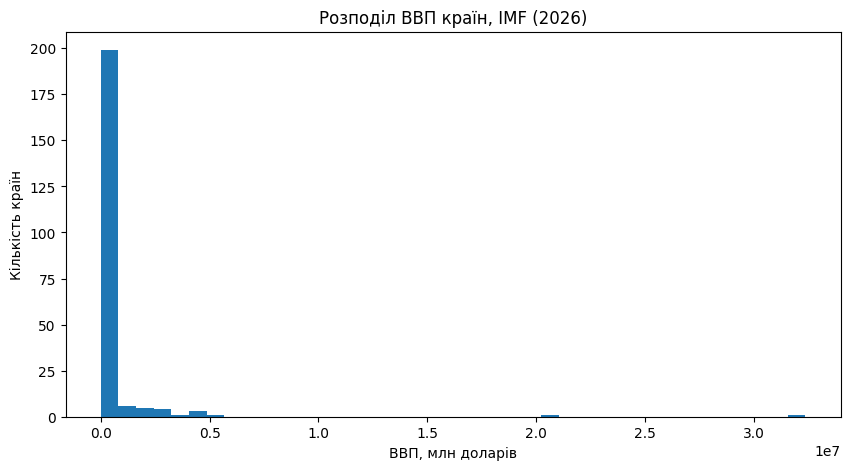

Асиметрія: 9.78
          Country  IMF (2026)
0   United States  32383920.0
1           China  20851593.0
2         Germany   5452858.0
3           Japan   4379253.0
4  United Kingdom   4264794.0


In [23]:
plt.figure(figsize=(10, 5))
plt.hist(df["IMF (2026)"], bins=40)
plt.title("Розподіл ВВП країн, IMF (2026)")
plt.xlabel("ВВП, млн доларів")
plt.ylabel("Кількість країн")
plt.show()

print("Асиметрія:", round(df["IMF (2026)"].skew(), 2))
print(df.nlargest(5, "IMF (2026)")[["Country", "IMF (2026)"]])

**Відповідь:** розподіл дуже несиметричний, скошений вправо (асиметрія майже 10). Більшість країн мають порівняно невеликий ВВП і потрапляють у перший стовпчик гістограми. Сильно виділяються США і Китай, менше Німеччина, Японія і Велика Британія.

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [24]:
# значення, заповнені середнім, сильно завищують загальну суму,
# тому частки рахуємо по країнах без пропусків
real = df[~had_nan]

# частка країни = її ВВП / сума ВВП всіх країн * 100
shares = real[cols] / real[cols].sum() * 100
shares.insert(0, "Country", real["Country"])
shares["Зміна з 2024 по 2026"] = shares["IMF (2026)"] - shares["United Nations (2024)"]

print("Частки 10 найбільших економік, %:")
display(shares.sort_values("IMF (2026)", ascending=False).head(10).round(2))

print("Найбільше зросла частка:")
display(shares.sort_values("Зміна з 2024 по 2026", ascending=False).head(5).round(3))
print("Найбільше впала частка:")
display(shares.sort_values("Зміна з 2024 по 2026").head(5).round(3))

Частки 10 найбільших економік, %:


,Country,IMF (2026),World Bank (2025),United Nations (2024),Зміна з 2024 по 2026
0,United States,25.84,26.27,26.53,-0.69
1,China,16.64,16.65,16.97,-0.34
2,Germany,4.35,4.31,4.22,0.13
3,Japan,3.49,3.79,3.65,-0.15
4,United Kingdom,3.40,3.42,3.34,0.07
5,India,3.31,3.38,3.58,-0.27
6,France,2.87,2.87,2.86,0.01
7,Italy,2.18,2.18,2.16,0.03
8,Russia,2.12,2.19,1.97,0.15
9,Brazil,2.10,1.95,1.98,0.12


Найбільше зросла частка:


,Country,IMF (2026),World Bank (2025),United Nations (2024),Зміна з 2024 по 2026
8,Russia,2.119,2.187,1.968,0.151
2,Germany,4.350,4.312,4.219,0.131
9,Brazil,2.103,1.946,1.979,0.124
15,Turkey,1.309,1.364,1.198,0.110
13,Spain,1.668,1.628,1.560,0.109


Найбільше впала частка:


,Country,IMF (2026),World Bank (2025),United Nations (2024),Зміна з 2024 по 2026
0,United States,25.837,26.270,26.528,-0.691
1,China,16.636,16.647,16.972,-0.336
5,India,3.314,3.378,3.579,-0.265
52,Iran,0.240,0.310,0.406,-0.166
14,South Korea,1.541,1.599,1.698,-0.157


**Відповідь:** частки змінюються мало, в основному на десяті частки відсотка. Найбільші частки у США (близько 26%) і Китаю (близько 17%), і саме в них частка трохи зменшується з 2024 до 2026 (у США з 26,5% до 25,8%). Найбільше частка виросла у Росії, Німеччини і Бразилії.

Частки рахували тільки по країнах без пропусків, бо значення, заповнені середнім, завищують загальну суму.

15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

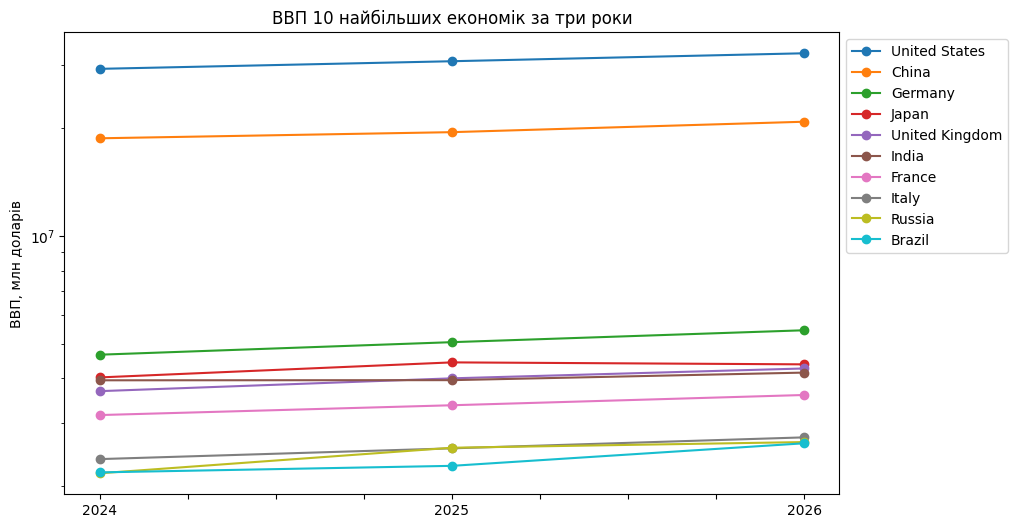

Країн всього: 196
Стабільно ростуть: 159
Стабільно падають: 2 ['Iran', 'Ethiopia']
Без чіткої тенденції: 35


In [25]:
years = ["United Nations (2024)", "World Bank (2025)", "IMF (2026)"]

# всі 200+ країн на одному графіку не прочитати, тому беремо 10 найбільших
top10 = df.nlargest(10, "IMF (2026)").set_index("Country")[years]
top10.columns = ["2024", "2025", "2026"]
top10.T.plot(marker="o", figsize=(10, 6))
plt.title("ВВП 10 найбільших економік за три роки")
plt.ylabel("ВВП, млн доларів")
plt.yscale("log")  # логарифмічна шкала, бо США і Китай набагато більші за інших
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

# для всіх країн (без тих, де були пропуски) рахуємо, хто росте або падає всі три роки
real = df[~had_nan]
growth = (real[years[0]] < real[years[1]]) & (real[years[1]] < real[years[2]])
fall = (real[years[0]] > real[years[1]]) & (real[years[1]] > real[years[2]])
print("Країн всього:", len(real))
print("Стабільно ростуть:", growth.sum())
print("Стабільно падають:", fall.sum(), real.loc[fall, "Country"].tolist())
print("Без чіткої тенденції:", len(real) - growth.sum() - fall.sum())

**Відповідь:** з 10 найбільших економік стабільно ростуть 9, тільки Японія у 2025 виросла, а у 2026 трохи впала. Серед усіх країн без пропусків стабільно ростуть 159 з 196, стабільно падають тільки Іран і Ефіопія, у решти 35 немає чіткої тенденції.

Треба враховувати, що три стовпці взяті з різних джерел (ООН, Світовий банк, МВФ), тому це не зовсім один і той самий показник по роках.